<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-6 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> RNN for Time Series </h2> </html>


RNNs are used for sequence modelling. This tutorial will look at time series data to be modelled and predicted using RNNs. 

In [1]:
# Import Libraries (pandas, numpy, matplotlib)

# ....
# ...
# ...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data

We will use retail data for time-series modeling. 

Link to the dataset:
 https://fred.stlouisfed.org/series/MRTSSM448USN

Information about the Advance Monthly Retail Sales Survey can be found on the Census website at:
https://www.census.gov/retail/marts/about_the_surveys.html

Release: Advance Monthly Sales for Retail and Food Services  
Units:  Millions of Dollars, Not Seasonally Adjusted
Frequency:  Monthly

Suggested Citation:
U.S. Census Bureau, Advance Retail Sales: Clothing and Clothing Accessory Stores [RSCCASN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RSCCASN, January 25, 2025.



##### Read data first -  Use index_col = 'DATE' and 'parse_dates = True' as a parameter.

_________________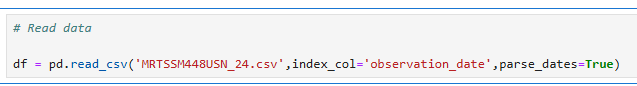

In [2]:
df = pd.read_csv('MRTSSM448USN_24-1.csv', index_col='observation_date', parse_dates=True)
df.head(2)

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524


In [ ]:
#pd.read_csv

In [23]:
# Print the first few rows of data
#d
# ...

In [8]:
df.head(10)

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
1992-06-01,9182
1992-07-01,9103
1992-08-01,10513
1992-09-01,9573


,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


_______________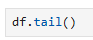

In [9]:
df.tail()

,MRTSSM448USN
observation_date,
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318
2024-11-01,29762
2024-12-01,41199


,MRTSSM448USN
observation_date,
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318
2024-11-01,29762
2024-12-01,41199


Does the sales column has any name?

If no, set the name of the colum as 'Sales'.

In [3]:
# Set name of column as 'Sales'. Use - df.columns 

# ...
df = df.rename({'MRTSSM448USN': 'Sales',
          'observation_date': 'Observation_Date'}, axis=1)
df.head()

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


Plot your data - Year vs Sales

hint: use df.plot  and plt.show()

____________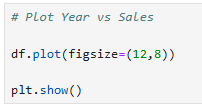

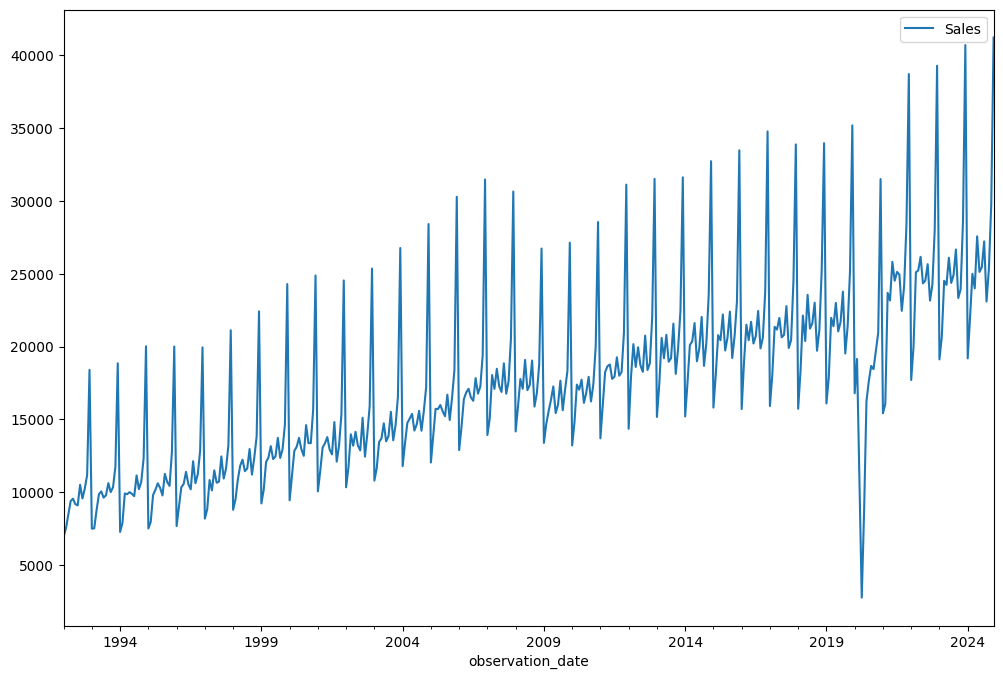

In [4]:
df.plot(figsize=(12,8))
plt.show()

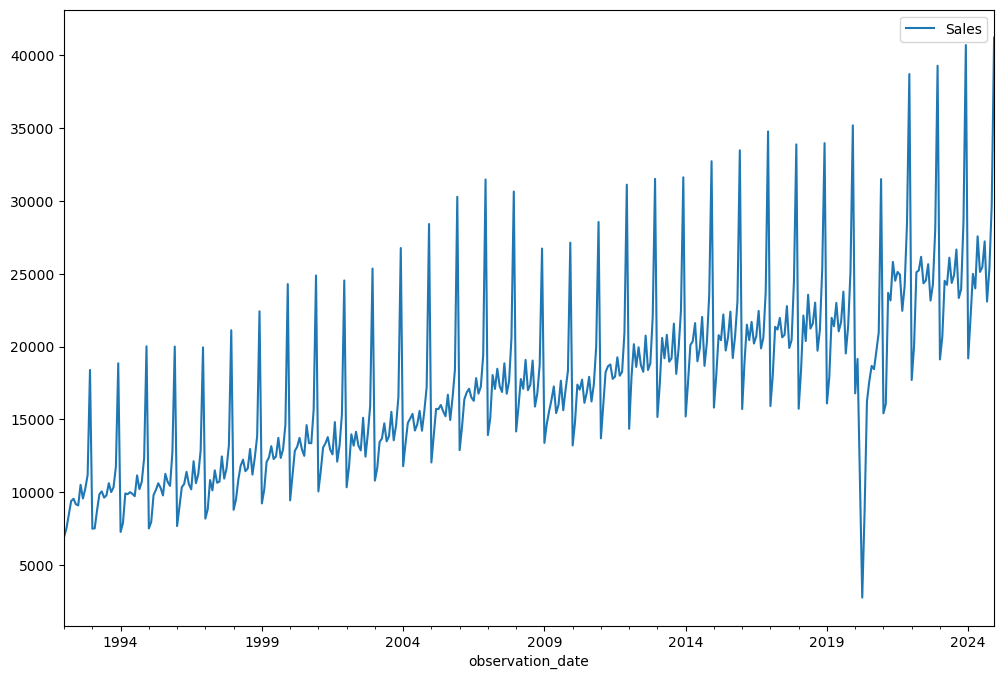

### Train Test Split 

We will use the last 1.5 years (18 months) samples for testing. The rest is for training

______________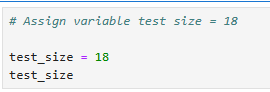

In [5]:
test_size = 18
test_size

18

18

__________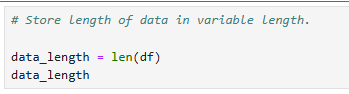

In [6]:
data_length = len(df)
data_length

396

396

__________________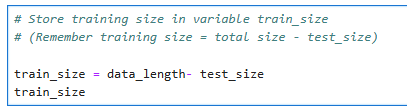

In [7]:
train_size = data_length - test_size
train_size

378

378

Now, we will find the indexes of the test data. Remember, these are the last 18 indexes in the pandas dataframe.

____________________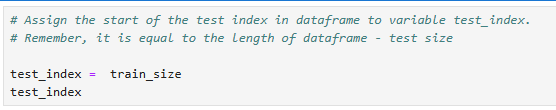

In [8]:
test_index = train_size
test_index

378

378

Next, we will separate train and test datasets.

_________________________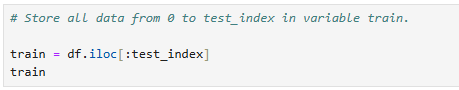

In [9]:
train = df.iloc[:test_index]
train.head()

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2023-02-01,20666
2023-03-01,24510
2023-04-01,24232


In [10]:
# Store everything from test_index to the last sample in the test variable 
# Hint - Use df.iloc

# ...
# ...
test = df.iloc[test_index:]
test

,Sales
observation_date,
2023-07-01,24911
2023-08-01,26657
2023-09-01,23332
2023-10-01,23933
2023-11-01,28580
2023-12-01,40684
2024-01-01,19188
2024-02-01,22005
2024-03-01,24986


,Sales
observation_date,
2023-07-01,24911
2023-08-01,26657
2023-09-01,23332
2023-10-01,23933
2023-11-01,28580
2023-12-01,40684
2024-01-01,19188
2024-02-01,22005
2024-03-01,24986


In [11]:
# Print the size of the train data

# ...

# Print the size of the test data

# ...
train.shape, test.shape


((378, 1), (18, 1))

378
18


### In Neural Networks, we need to Scale Data between 0-1

___________________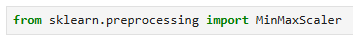

In [12]:
from sklearn.preprocessing import MinMaxScaler

_______________________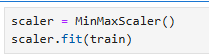

In [13]:
scaler = MinMaxScaler()
scaler.fit(train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


MinMaxScaler()

__________________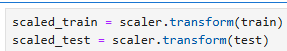

In [14]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [15]:
# Check if the data has been scaled properly
# Print max and min for train and test

# ...
# ...
# ...
# ...
scaled_train.min(), scaled_train.max(), scaled_test.min(), scaled_test.max()

(np.float64(0.0),
 np.float64(1.0),
 np.float64(0.44980403979499545),
 np.float64(1.0530599939704552))

1.0
1.0530599939704552
0.0
0.44980403979499545


## Time Series Generator

This class takes in a sequence of data points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.

#### Arguments
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, timesteps
        `data[i]`, `data[i-r]`, ... `data[i - length]`
        are used for create a sample sequence.
    stride: Period between successive output sequences.
        For stride `s`, consecutive output samples would
        be centered around `data[i]`, `data[i+s]`, `data[i+2*s]`, etc.
    start_index: Data points earlier than `start_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    end_index: Data points later than `end_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    shuffle: Whether to shuffle output samples,
        or instead draw them in chronological order.
    reverse: Boolean: if `true`, timesteps in each output sample will be
        in reverse chronological order.
    batch_size: Number of timeseries samples in each batch
        (except maybe the last one).

### We will use 12 months as input and then predict the next month out


In [16]:
import tensorflow

c:\Users\peter\.conda\envs\py311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


_____________________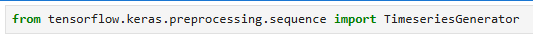

In [17]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [18]:
TimeseriesGenerator?

Init signature:
TimeseriesGenerator(
    data,
    targets,
    length,
    sampling_rate=1,
    stride=1,
    start_index=0,
    end_index=None,
    shuffle=False,
    reverse=False,
    batch_size=128,
    **kwargs,
)
Docstring:     
Utility class for generating batches of temporal data.

DEPRECATED.

This class takes in a sequence of data-points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.

Arguments:
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, ti

In [70]:
#TimeseriesGenerator?

_________________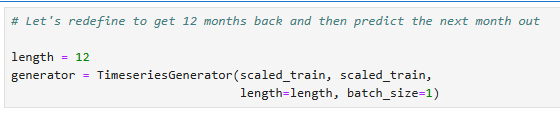

In [20]:
length = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, length=length, batch_size=1)

In [28]:
generator?


Type:        TimeseriesGenerator
String form: <keras.src.legacy.preprocessing.sequence.TimeseriesGenerator object at 0x00000175EC52F410>
Length:      366
File:        c:\users\peter\.conda\envs\py311\lib\site-packages\keras\src\legacy\preprocessing\sequence.py
Docstring:  
Utility class for generating batches of temporal data.

DEPRECATED.

This class takes in a sequence of data-points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.

Arguments:
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
    

_______________________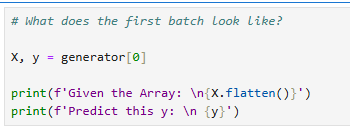

In [21]:
X, y = generator[0]
print(f'Given the array: {X.flatten()}')
print(f'Predict this y: {y}')

Given the array: [0.11406802 0.13012854 0.15619262 0.18157152 0.18587442 0.17556938
 0.17340423 0.21204813 0.18628553 0.20494971 0.23052046 0.42807027]
Predict this y: [[0.12952558]]


Given the Array: 
[0.11406802 0.13012854 0.15619262 0.18157152 0.18587442 0.17556938
 0.17340423 0.21204813 0.18628553 0.20494971 0.23052046 0.42807027]
Predict this y: 
 [[0.12952558]]


### Create the Model

__________________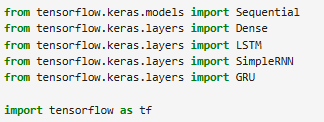

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, GRU, Input

________________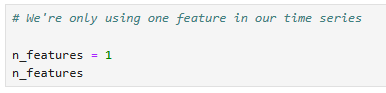

In [24]:
n_features = 1

1

## Define your own models. 

Use 1. SimpleRNN, LSTM, or GRU neural network.

APIs:
https://keras.io/api/layers/recurrent_layers/

In [25]:
length

12

In [29]:
# Your code to create your own model
# use input_shape=(length, n_features)
# use model.add(Dense(1)) because it is the regression task
 
# .....
# .....
# .....
model = Sequential([
    Input(shape=(12, 1)),
    
    LSTM(200, activation='relu', return_sequences=True),
    LSTM(200, activation='relu'),
    Dense(1)
])

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 200)        │       161,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 200)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 482,601 (1.84 MB)

 Trainable params: 482,601 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

_____________________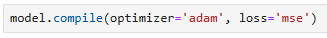

In [31]:
model.compile(optimizer='adam', loss='mse')

### EarlyStopping and creating a Validation Generator

NOTE: The scaled_test dataset size MUST be greater than your length chosen for your batches. 

Review the video on the Week-6 page for more info on this.

____________________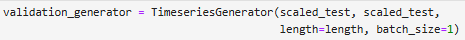

In [32]:
validation_generator = TimeseriesGenerator(scaled_test, scaled_test, length=length, batch_size=1)

___________________

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

In [34]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

# LAST_DIGIT_IN_YOUR_SID = 

early_stop = EarlyStopping(monitor='val_loss',patience=5)


_____________________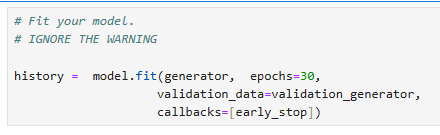

In [35]:
history = model.fit(generator, epochs = 30, validation_data=validation_generator, callbacks=[early_stop])

Epoch 1/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - loss: 0.0199 - val_loss: 0.0308
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - loss: 0.0139 - val_loss: 0.0096
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0082 - val_loss: 0.0028
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - loss: 0.0066 - val_loss: 3.8436e-04
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - loss: 0.0049 - val_loss: 0.0040
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0051 - val_loss: 0.0027
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.0043 - val_loss: 0.0121
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.0047 - val_loss: 7.5836e-04
Epoch 9/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 0.0048 - val_loss: 9.9762e-04


C:\Users\vital\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.0364 - val_loss: 0.0283
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0124 - val_loss: 0.0153
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0118 - val_loss: 0.0010
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0068 - val_loss: 0.0032
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0047 - val_loss: 0.0127
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0079 - val_loss: 0.0011
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0037 - val_loss: 0.0011
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 9/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0046 - val_loss: 0.0026
Epoch 10/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0042 - val_loss: 6.1039e-04
Epoch 11/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0049 - val_loss: 6.4973e-04
Epoch 12/30
366/366 ━━━━━━━━━━━━

_____________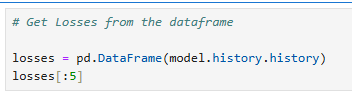

In [36]:
losses = pd.DataFrame(model.history.history)
losses[:5]

,loss,val_loss
0,0.019876,0.030823
1,0.013900,0.009611
2,0.008227,0.002835
3,0.006564,0.000384
4,0.004917,0.004048


In [124]:
# the values may be different


,loss,val_loss
0,0.020090,0.028262
1,0.012648,0.015266
2,0.010198,0.001036
3,0.006880,0.003225
4,0.005237,0.012703


___________________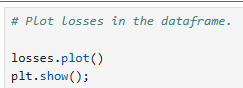

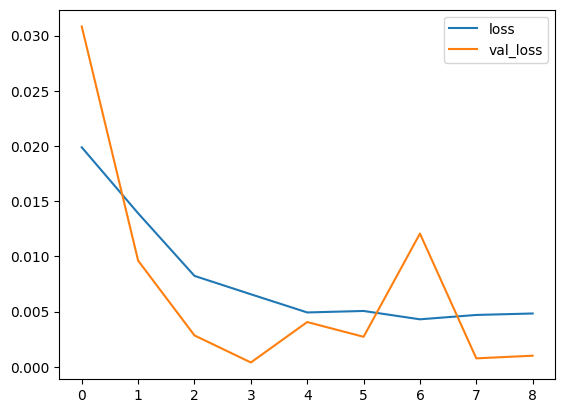

In [37]:
losses.plot()
plt.show()

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

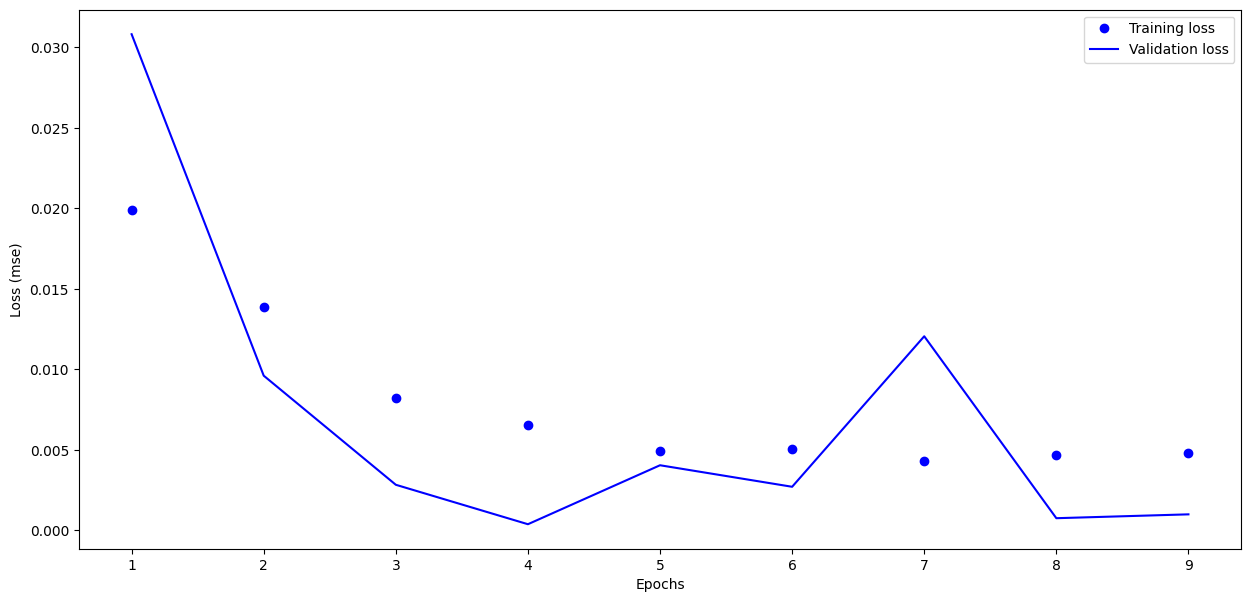

In [38]:
# print Loss for the neural network training process

history_dict = history.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')


plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

### Evaluate on Test Data

____________________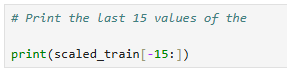

In [39]:
print(scaled_train[-15:])

[[0.61523282]
 [0.64077617]
 [0.5909502 ]
 [0.59621235]
 [0.62693562]
 [0.55844547]
 [0.58834653]
 [0.69254803]
 [1.        ]
 [0.44788555]
 [0.49031162]
 [0.59566421]
 [0.58804506]
 [0.63913175]
 [0.59166278]]


[[0.61523282]
 [0.64077617]
 [0.5909502 ]
 [0.59621235]
 [0.62693562]
 [0.55844547]
 [0.58834653]
 [0.69254803]
 [1.        ]
 [0.44788555]
 [0.49031162]
 [0.59566421]
 [0.58804506]
 [0.63913175]
 [0.59166278]]


____________________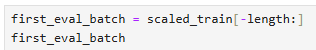

In [40]:
first_eval_batch = scaled_train[-length:]

first_eval_batch

array([[0.59621235],
       [0.62693562],
       [0.55844547],
       [0.58834653],
       [0.69254803],
       [1.        ],
       [0.44788555],
       [0.49031162],
       [0.59566421],
       [0.58804506],
       [0.63913175],
       [0.59166278]])

array([[0.59621235],
       [0.62693562],
       [0.55844547],
       [0.58834653],
       [0.69254803],
       [1.        ],
       [0.44788555],
       [0.49031162],
       [0.59566421],
       [0.58804506],
       [0.63913175],
       [0.59166278]])

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [41]:
n_input = 12
first_eval_batch = first_eval_batch.reshape((1, n_input, n_features))
first_eval_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

___________________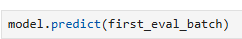

In [42]:
model.predict(first_eval_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.6194075]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step


array([[0.63285655]], dtype=float32)

_________________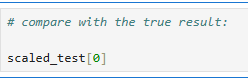

In [43]:
scaled_test[0]

array([0.60665442])

array([0.60665442])

#### Try predicting the series!

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [47]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

current_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

____________________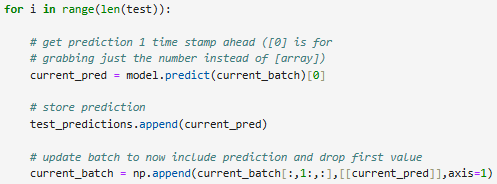

In [55]:
current_pred = model.predict(current_batch)[0]
current_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


array([0.6194075], dtype=float32)

In [56]:
for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


______________________

In [57]:
test_predictions

[array([0.6194075], dtype=float32),
 array([0.648736], dtype=float32),
 array([0.58623874], dtype=float32),
 array([0.61646223], dtype=float32),
 array([0.7282746], dtype=float32),
 array([0.97193855], dtype=float32),
 array([0.5011213], dtype=float32),
 array([0.53733766], dtype=float32),
 array([0.6229478], dtype=float32),
 array([0.6157644], dtype=float32),
 array([0.66396093], dtype=float32),
 array([0.6187125], dtype=float32),
 array([0.64500546], dtype=float32),
 array([0.67344844], dtype=float32),
 array([0.6147424], dtype=float32),
 array([0.6442908], dtype=float32),
 array([0.7624227], dtype=float32),
 array([0.96130854], dtype=float32)]

[array([0.63285655], dtype=float32),
 array([0.655915], dtype=float32),
 array([0.60953766], dtype=float32),
 array([0.63251466], dtype=float32),
 array([0.7280531], dtype=float32),
 array([1.0275557], dtype=float32),
 array([0.494833], dtype=float32),
 array([0.53379714], dtype=float32),
 array([0.6105526], dtype=float32),
 array([0.62500674], dtype=float32),
 array([0.66780484], dtype=float32),
 array([0.6402486], dtype=float32),
 array([0.66947997], dtype=float32),
 array([0.68683314], dtype=float32),
 array([0.65377283], dtype=float32),
 array([0.6738984], dtype=float32),
 array([0.7653416], dtype=float32),
 array([1.0579401], dtype=float32)]

### Inverse Transformations and Compare

_________________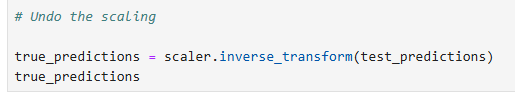

In [58]:
true_predictions = scaler.inverse_transform(test_predictions)
true_predictions

array([[25376.32054013],
       [26446.43043423],
       [24166.09297478],
       [25268.85741091],
       [29348.55473971],
       [38239.12189108],
       [21060.41223741],
       [22381.83922923],
       [25505.49681938],
       [25243.39491487],
       [27001.94258738],
       [25350.96243423],
       [26310.31438518],
       [27348.1133548 ],
       [25206.10588539],
       [26284.23859704],
       [30594.51635635],
       [37851.26465935]])

array([[25867.03686076],
       [26708.37140393],
       [25016.20063967],
       [25854.56223851],
       [29340.47320271],
       [40268.42497611],
       [20830.97139931],
       [22252.6564256 ],
       [25053.23304337],
       [25580.6207518 ],
       [27142.1950959 ],
       [26136.75054663],
       [27203.31552541],
       [27836.48089719],
       [26630.20928335],
       [27364.5308798 ],
       [30701.01822633],
       [41377.06135786]])

_____________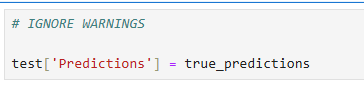

In [59]:
test['Predictions'] = true_predictions

C:\Users\peter\AppData\Local\Temp\ipykernel_15228\4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


C:\Users\vital\AppData\Local\Temp\ipykernel_18288\3095654106.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


### Check and plot predictions

In [60]:
test

,Sales,Predictions
observation_date,,
2023-07-01,24911,25376.320540
2023-08-01,26657,26446.430434
2023-09-01,23332,24166.092975
2023-10-01,23933,25268.857411
2023-11-01,28580,29348.554740
2023-12-01,40684,38239.121891
2024-01-01,19188,21060.412237
2024-02-01,22005,22381.839229
2024-03-01,24986,25505.496819


,Sales,Predictions
observation_date,,
2023-07-01,24911,25867.036861
2023-08-01,26657,26708.371404
2023-09-01,23332,25016.200640
2023-10-01,23933,25854.562239
2023-11-01,28580,29340.473203
2023-12-01,40684,40268.424976
2024-01-01,19188,20830.971399
2024-02-01,22005,22252.656426
2024-03-01,24986,25053.233043


_______________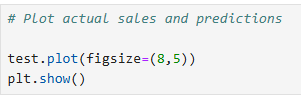

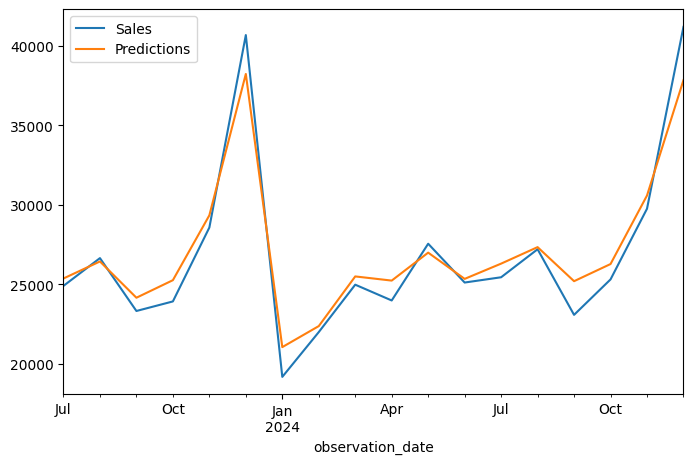

In [61]:
test.plot(figsize=(8,5))
plt.show()

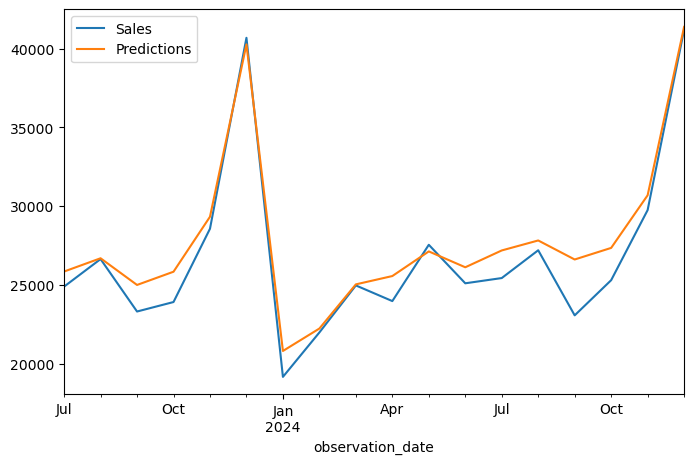

### Retrain and Forecasting

_________________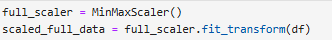

In [62]:
full_scaler = MinMaxScaler()
scaled_full_data = full_scaler.fit_transform(df)

______________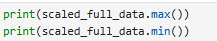

1.0
0.0


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [63]:
length = 12 # Length of the output sequences (in number of timesteps)
generator = TimeseriesGenerator(scaled_full_data, 
                                scaled_full_data, length=length, batch_size=1)

In [65]:
# Use any neural network model based on RNN
# You can also use the model created above
#
# Create the model

# ...
# ...
# ...
model = Sequential([
    Input(shape=(12, 1)),
    LSTM(250, activation='relu', return_sequences=True),
    LSTM(250, activation='relu'),
    Dense(1)
])

C:\Users\vital\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [66]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 250)        │       252,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 250)            │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 753,251 (2.87 MB)

 Trainable params: 753,251 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# your code to compile the model

# ...


model.compile(optimizer='adam', loss='mse')

In [ ]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

LAST_DIGIT_IN_YOUR_SID = 5

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)


____________________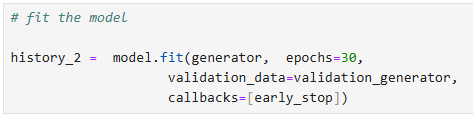

In [69]:
history2 = model.fit(generator, epochs=20, validation_data=validation_generator, callbacks=[early_stop])

Epoch 1/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 0.0176 - val_loss: 0.0346
Epoch 2/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - loss: 0.0101 - val_loss: 0.0041
Epoch 3/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - loss: 0.0067 - val_loss: 0.0128
Epoch 4/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 0.0053 - val_loss: 0.0077
Epoch 5/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 0.0043 - val_loss: 9.5926e-04
Epoch 6/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - loss: 0.0041 - val_loss: 3.5799e-04
Epoch 7/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 0.0040 - val_loss: 0.0022
Epoch 8/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - loss: 0.0040 - val_loss: 0.0012
Epoch 9/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.0036 - val_loss: 0.0172
Epoch 10/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - loss: 0.0037 - val_loss: 0.0011
Epoch 11/20
384/384 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - loss: 0.0036 - val_loss: 3.3723e-04
Epoch 12/20
384/38

In [70]:
# fit the model

history_2 =  model.fit(generator,  epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0026 - val_loss: 0.0043
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - loss: 0.0023 - val_loss: 8.8549e-04
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.0021 - val_loss: 0.0046
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.0022 - val_loss: 9.8193e-04
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.0021 - val_loss: 0.0027


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [72]:
forecast = []
periods = 12

first_eval_batch = scaled_full_data[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

for i in range(periods):
    current_pred = model.predict(current_batch)[0]
    forecast.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


______________________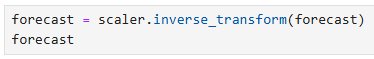

In [73]:
forecast = scaler.inverse_transform(forecast)
forecast

array([[20440.96220824],
       [23294.18734288],
       [25553.33577782],
       [25530.30470222],
       [28553.34759158],
       [27618.81439745],
       [27724.07663447],
       [29585.1049816 ],
       [26426.29618514],
       [27298.87817818],
       [30188.46696717],
       [40597.61929631]])

array([[18620.61448288],
       [20206.91406763],
       [22167.73939276],
       [21757.40348327],
       [23828.92585731],
       [22448.01823115],
       [22479.73978627],
       [23555.70857722],
       [21352.45454019],
       [22294.99097872],
       [25707.46347636],
       [37294.23667431]])

### Creating new timestamp index with pandas.

<html> <h4 style="font-style:italic; color:blue;"> Just run the 4 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [74]:
df

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318


##### Forecast for next 12 months

__________________

In [75]:
forecast_index = pd.date_range(start='2025-01-01', periods=periods, freq='MS')

__________________________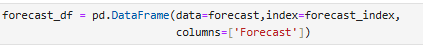

In [76]:
forecase_df = pd.DataFrame(forecast, index=forecast_index, columns=['Forecast'])

________________________

In [77]:
forecase_df

,Forecast
2025-01-01,20440.962208
2025-02-01,23294.187343
2025-03-01,25553.335778
2025-04-01,25530.304702
2025-05-01,28553.347592
2025-06-01,27618.814397
2025-07-01,27724.076634
2025-08-01,29585.104982
2025-09-01,26426.296185
2025-10-01,27298.878178


,Forecast
2025-01-01,18620.614483
2025-02-01,20206.914068
2025-03-01,22167.739393
2025-04-01,21757.403483
2025-05-01,23828.925857
2025-06-01,22448.018231
2025-07-01,22479.739786
2025-08-01,23555.708577
2025-09-01,21352.454540
2025-10-01,22294.990979


__________________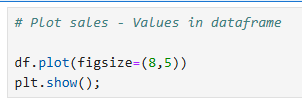

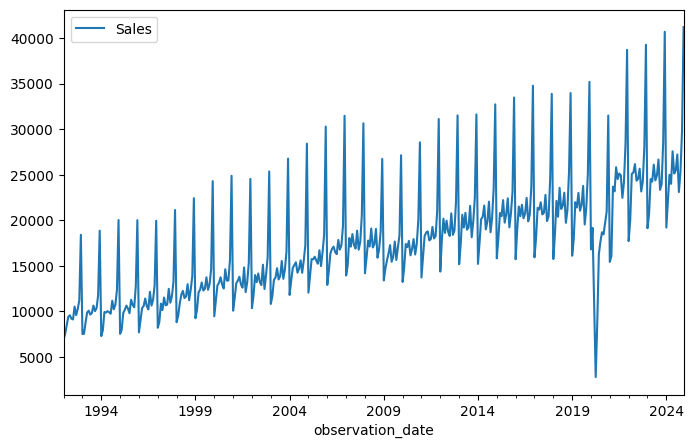

In [78]:
df.plot(figsize=(8,5))
plt.show()

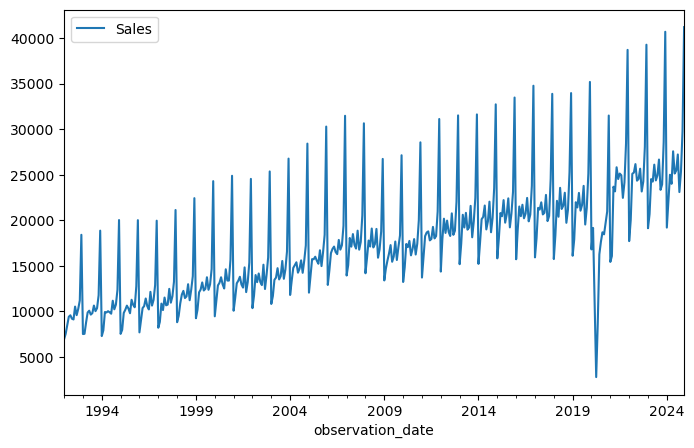

____________________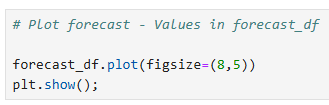

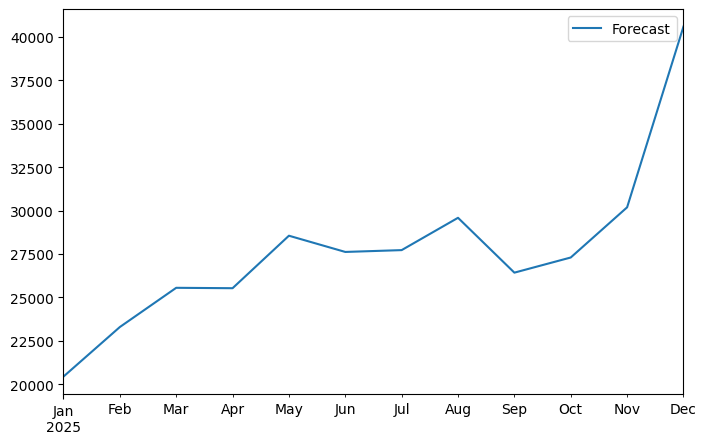

In [79]:
forecase_df.plot(figsize=(8,5))
plt.show()

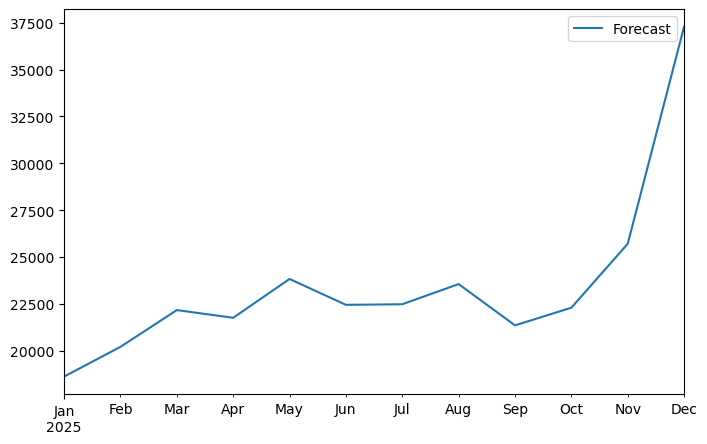

### Joining pandas plots

https://stackoverflow.com/questions/13872533/plot-different-dataframes-in-the-same-figure

________________________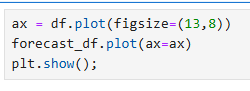

<Axes: xlabel='observation_date'>

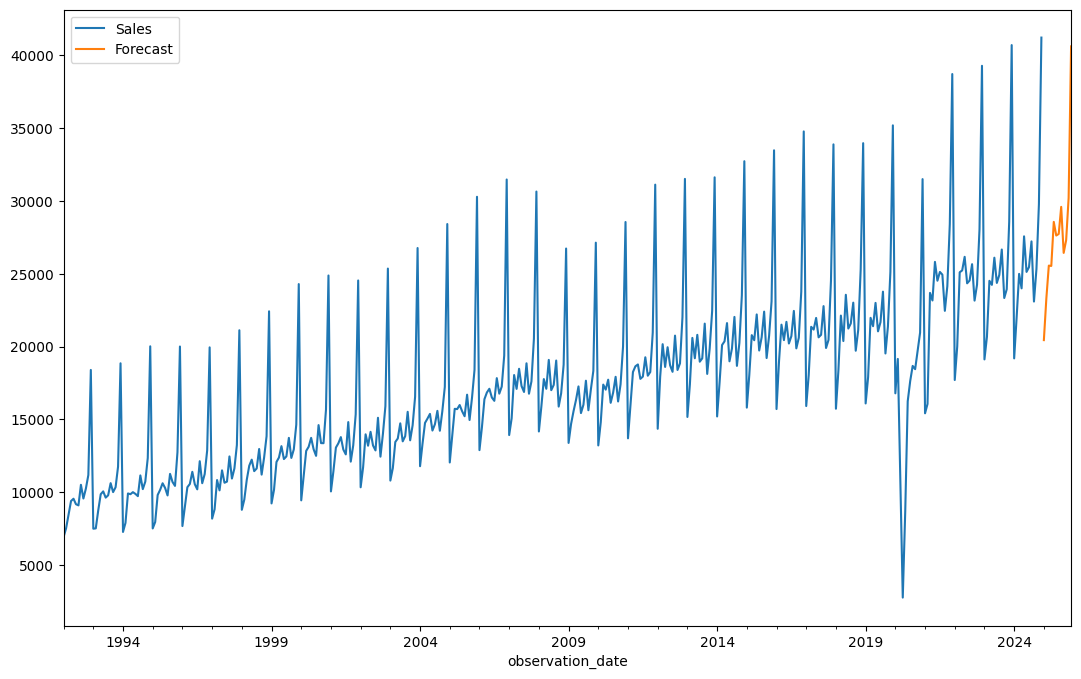

In [ ]:
ax = df.plot(figsize=(13,8))
forecase_df.plot(ax=ax)



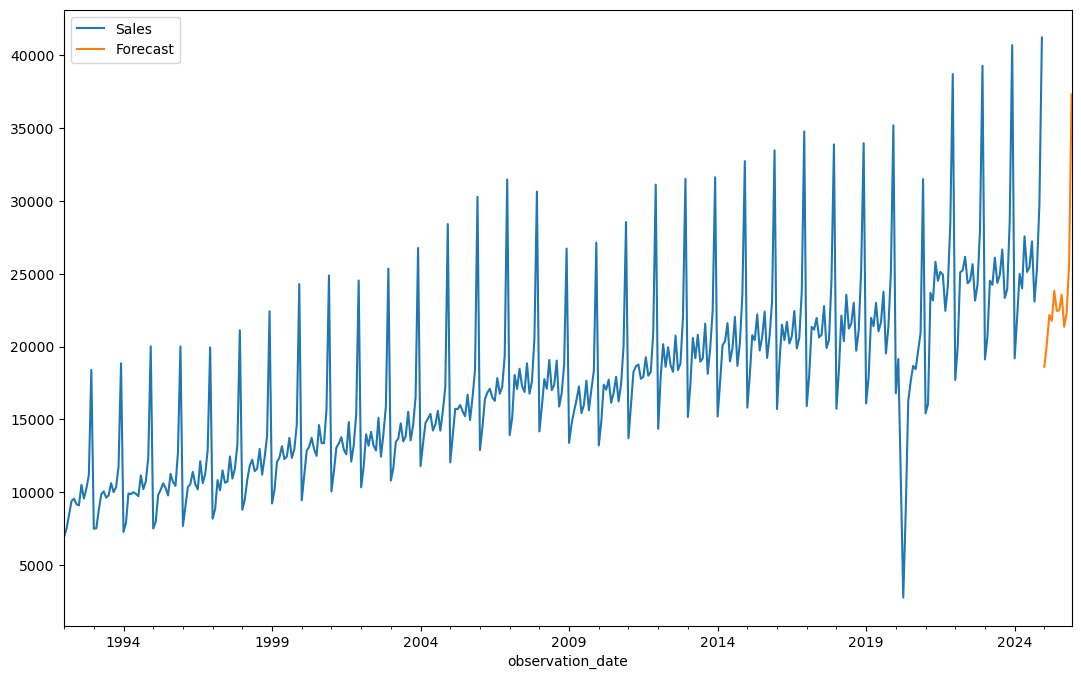

_______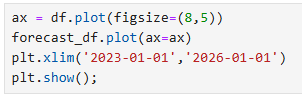

(636.0, 672.0)

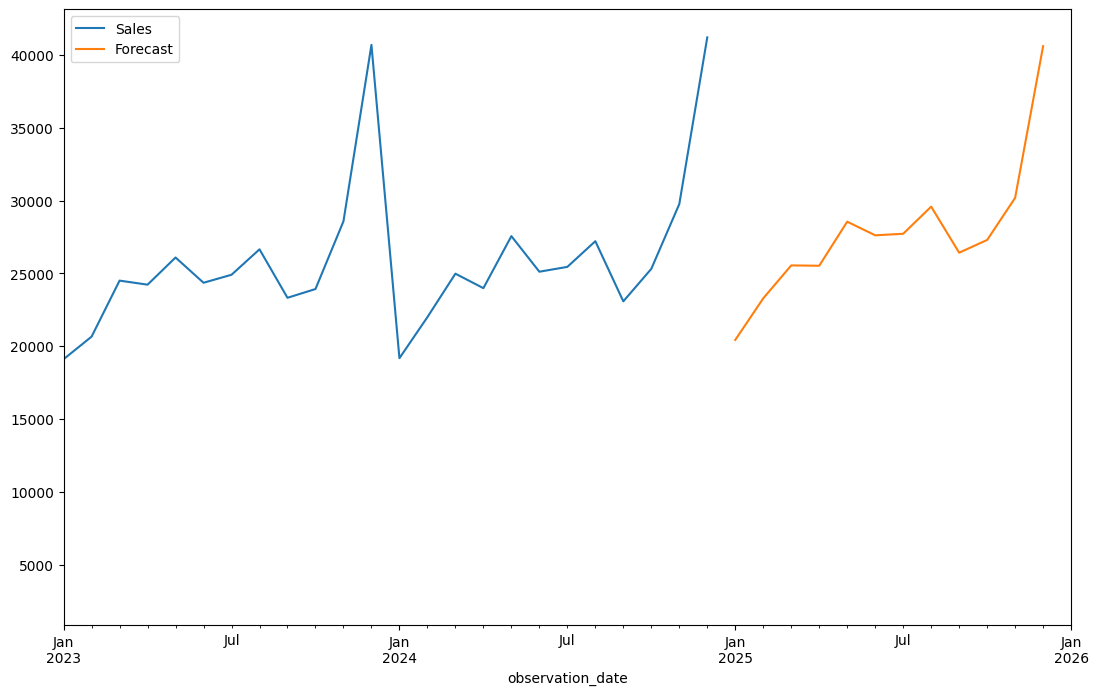

In [83]:
ax = df.plot(figsize=(13,8))
forecase_df.plot(ax=ax)
plt.xlim('2023-01-01', '2026-01-01')



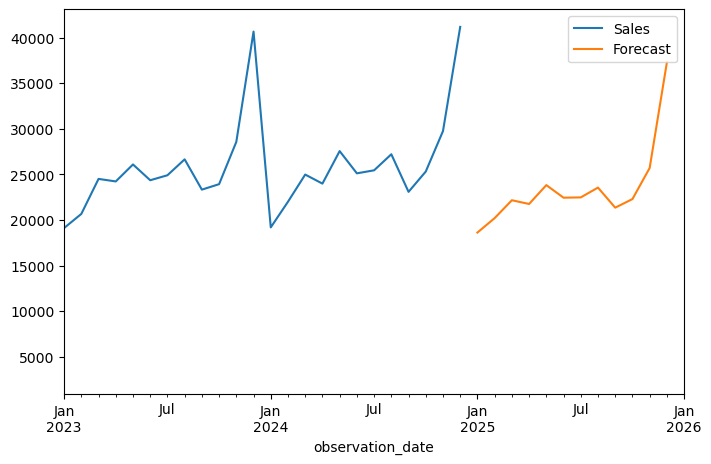

### Checking Forecast for last 12 months

_______________________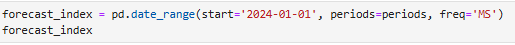

In [86]:
forecast_index = pd.date_range(start='2024-01-01', periods=periods, freq='MS')
forecast_index

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

________________________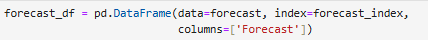

In [87]:
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=['Forecast'])

___________________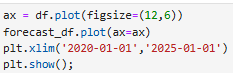

(600.0, 660.0)

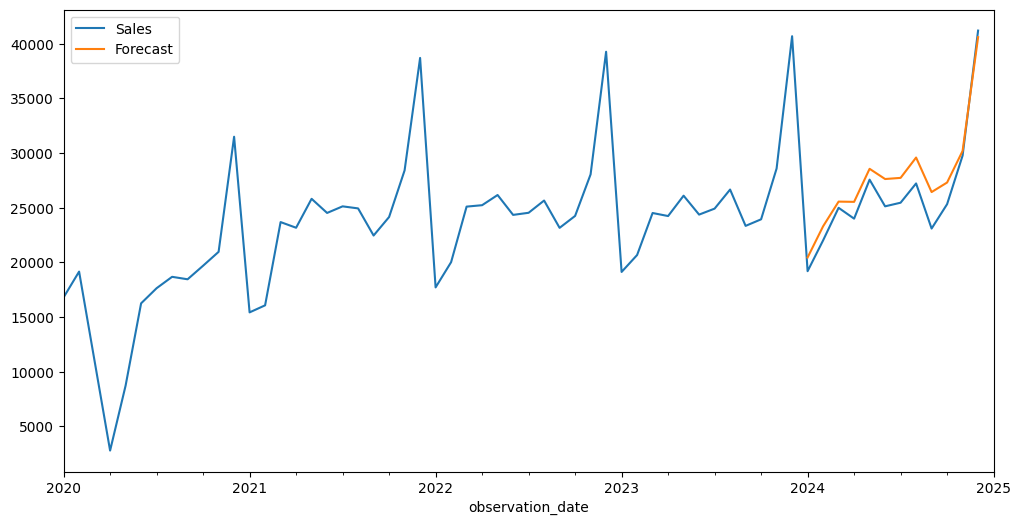

In [89]:
ax = df.plot(figsize=(12,6))
forecast_df.plot(ax=ax)
plt.xlim('2020-01-01', '2025-01-01')



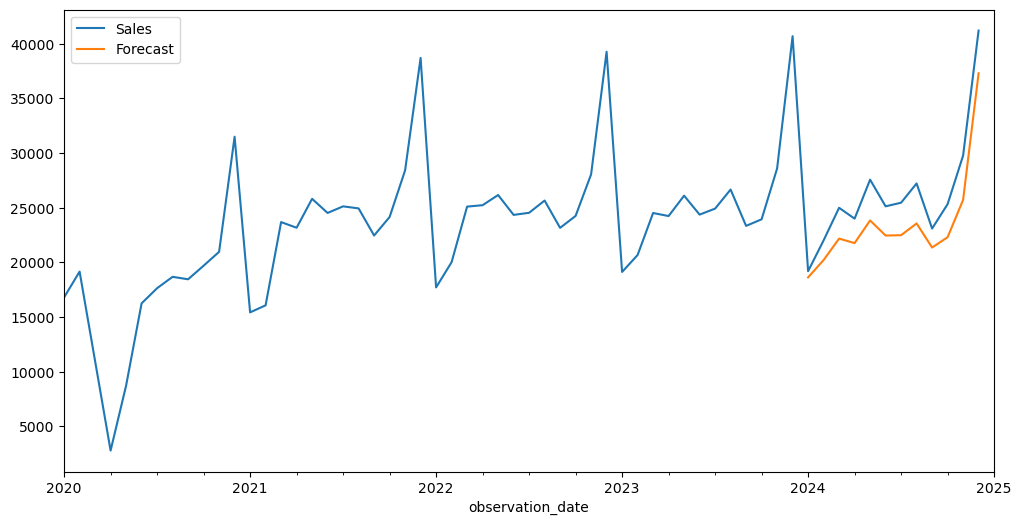

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Record the 2nd model's code & plot the summary()

### 2. Copy your early-stop code and history_2 fit-training-process

### 3. Record the plot of validation and test loss of history_2.

### 4. Based on this analysis, determine the optimal number of epochs for training your model. 

### 5. Record the plot of the Checking Forecast for the last 12 months (last graph).

### Try the same example with a LSTM and/or GRU! (Optional)
Hint: Use LSTM instead of SimpleRNN!